In [2]:
import sys
import os

# 1. Find the project root
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "../.."))

# 2. Add the 'src' folder specifically to the Python path
src_dir = os.path.join(project_root, "src")
if src_dir not in sys.path:
    sys.path.append(src_dir)

# 3. Import from your files!
from dataloaders import load_camera_data
from models import build_hbmnl_model, run_inference_hbmnl

print("Imports successful!")

Imports successful!


In [3]:
# 1. Define the Data Path
# Assuming you moved the data to the centralized folder as planned:
data_path = os.path.join(project_root, "data", "processed", "camera_data.json")

# Note: If you HAVEN'T moved the data yet, uncomment the line below instead:
# data_path = os.path.join(project_root, "HBMNL", "camera", "camera_data.json")

# 2. Load the Data
print(f"Loading data from: {data_path}")
data_dict = load_camera_data(data_path)
print(f"Data loaded successfully! Found {data_dict['n_units']} respondents and {data_dict['n_params']} parameters.")

# 3. Build the Model
# A_val sets the prior variance for the global mean (Delta or mu)
model = build_hbmnl_model(data_dict=data_dict, A_val=0.01)
print("HBMNL Model compiled successfully!")

# 4. Run Inference
# Note: For a quick test run, you might want to drop warmup to 500 and posterior to 1000.
# The settings below are for a full, standard run.
results, samples = run_inference_hbmnl(
    model=model, 
    data_dict=data_dict, 
    chains=4, 
    warmup=1000, 
    posterior=5000,
    seed=123
)

print("\nSampling Complete! The 'samples' dictionary now holds your posterior draws.")

Loading data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\data\processed\camera_data.json
Data loaded successfully! Found 332 respondents and 10 parameters.


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


HBMNL Model compiled successfully!


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling...
 - Targeting global parameter: mu
 - Chains: 4 | Warmup: 1000 | Posterior: 5000


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:19<00:00,  6.63s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 9, 8, 9, 8 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2, 0, 4, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 373.13chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 3, 4, 4, 4 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2, 3, 2, 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 2, 2, 2 / 25 transitions
liesel.goose.e


Sampling Complete! The 'samples' dictionary now holds your posterior draws.


In [12]:
# Setup plotting and data manipulation imports
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import liesel.goose as gs
import tensorflow_probability.substrates.jax.bijectors as tfb

# Define the parameter names for the Camera dataset
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

In [13]:
def generate_posterior_tables(samples, param_names):
    """Calculates posterior means and stds for Mu and the Covariance matrix."""
    k_dim = len(param_names)

    # Posterior distribution of Mu (or Delta if Z is present, but camera has no Z)
    # Note: Our new unified function dynamically names the global param "mu" or "Delta"
    global_param = "mu" if "mu" in samples else "Delta"
    
    mu_draws = samples[global_param].reshape(-1, k_dim)
    mu_mean = np.mean(mu_draws, axis=0)
    mu_std = np.std(mu_draws, axis=0)

    mu_df = pd.DataFrame({
        "Parameter": param_names,
        "Posterior Mean": mu_mean,
        "Std. Dev": mu_std
    }).set_index("Parameter")

    # Covariance / Correlation of Betas
    latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
    bijector = tfb.FillScaleTriL()

    v_latent_to_cov = jax.vmap(lambda v: jnp.linalg.inv(bijector.forward(v) @ bijector.forward(v).T))
    cov_draws = np.array(v_latent_to_cov(latent_samples)) 

    std_draws = np.sqrt(np.diagonal(cov_draws, axis1=1, axis2=2))
    outer_stds = std_draws[:, :, None] * std_draws[:, None, :]
    corr_draws = cov_draws / outer_stds

    std_mean, std_sd = np.mean(std_draws, axis=0), np.std(std_draws, axis=0)
    corr_mean, corr_sd = np.mean(corr_draws, axis=0), np.std(corr_draws, axis=0)

    cov_corr_df = pd.DataFrame(index=param_names, columns=param_names)

    for i in range(k_dim):
        for j in range(k_dim):
            if i == j:
                cov_corr_df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i:
                cov_corr_df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else:
                cov_corr_df.iloc[i, j] = ""

    return mu_df, cov_corr_df

# Generate and display tables
df_mu, df_cov_corr = generate_posterior_tables(samples, param_names)

print("=== Posterior distribution of Global Base Utilities ===")
display(df_mu)

print("\n=== Correlations and standard deviations of betas ===")
display(df_cov_corr)

=== Posterior distribution of Global Base Utilities ===


,Posterior Mean,Std. Dev
Parameter,,
Canon,2.013570,0.369837
Sony,1.583706,0.385002
Nikon,1.708568,0.380181
Panasonic,1.185026,0.379592
Pixels,1.428881,0.138934
Zoom,1.755125,0.140778
Video,1.332954,0.112886
Swivel,0.766880,0.111326
Wifi,1.205158,0.121717



=== Correlations and standard deviations of betas ===


,Canon,Sony,Nikon,Panasonic,Pixels,Zoom,Video,Swivel,Wifi,Price
Canon,5.75 (0.35),0.96 (0.01),0.97 (0.01),0.96 (0.01),-0.58 (0.06),-0.50 (0.07),-0.28 (0.09),-0.19 (0.09),-0.29 (0.08),-0.60 (0.05)
Sony,,6.02 (0.35),0.96 (0.01),0.98 (0.00),-0.52 (0.06),-0.49 (0.06),-0.28 (0.09),-0.17 (0.09),-0.24 (0.08),-0.61 (0.05)
Nikon,,,5.93 (0.35),0.96 (0.01),-0.56 (0.06),-0.54 (0.06),-0.29 (0.09),-0.19 (0.09),-0.27 (0.08),-0.58 (0.05)
Panasonic,,,,5.90 (0.35),-0.53 (0.06),-0.48 (0.07),-0.24 (0.09),-0.20 (0.09),-0.24 (0.08),-0.61 (0.05)
Pixels,,,,,1.95 (0.13),0.41 (0.07),0.09 (0.09),0.03 (0.09),-0.03 (0.09),0.38 (0.07)
Zoom,,,,,,1.94 (0.13),0.08 (0.10),-0.05 (0.09),0.17 (0.09),0.20 (0.08)
Video,,,,,,,1.40 (0.11),0.15 (0.10),0.11 (0.10),0.08 (0.09)
Swivel,,,,,,,,1.45 (0.11),0.14 (0.09),0.09 (0.09)
Wifi,,,,,,,,,1.60 (0.12),0.04 (0.09)
Price,,,,,,,,,,2.60 (0.16)


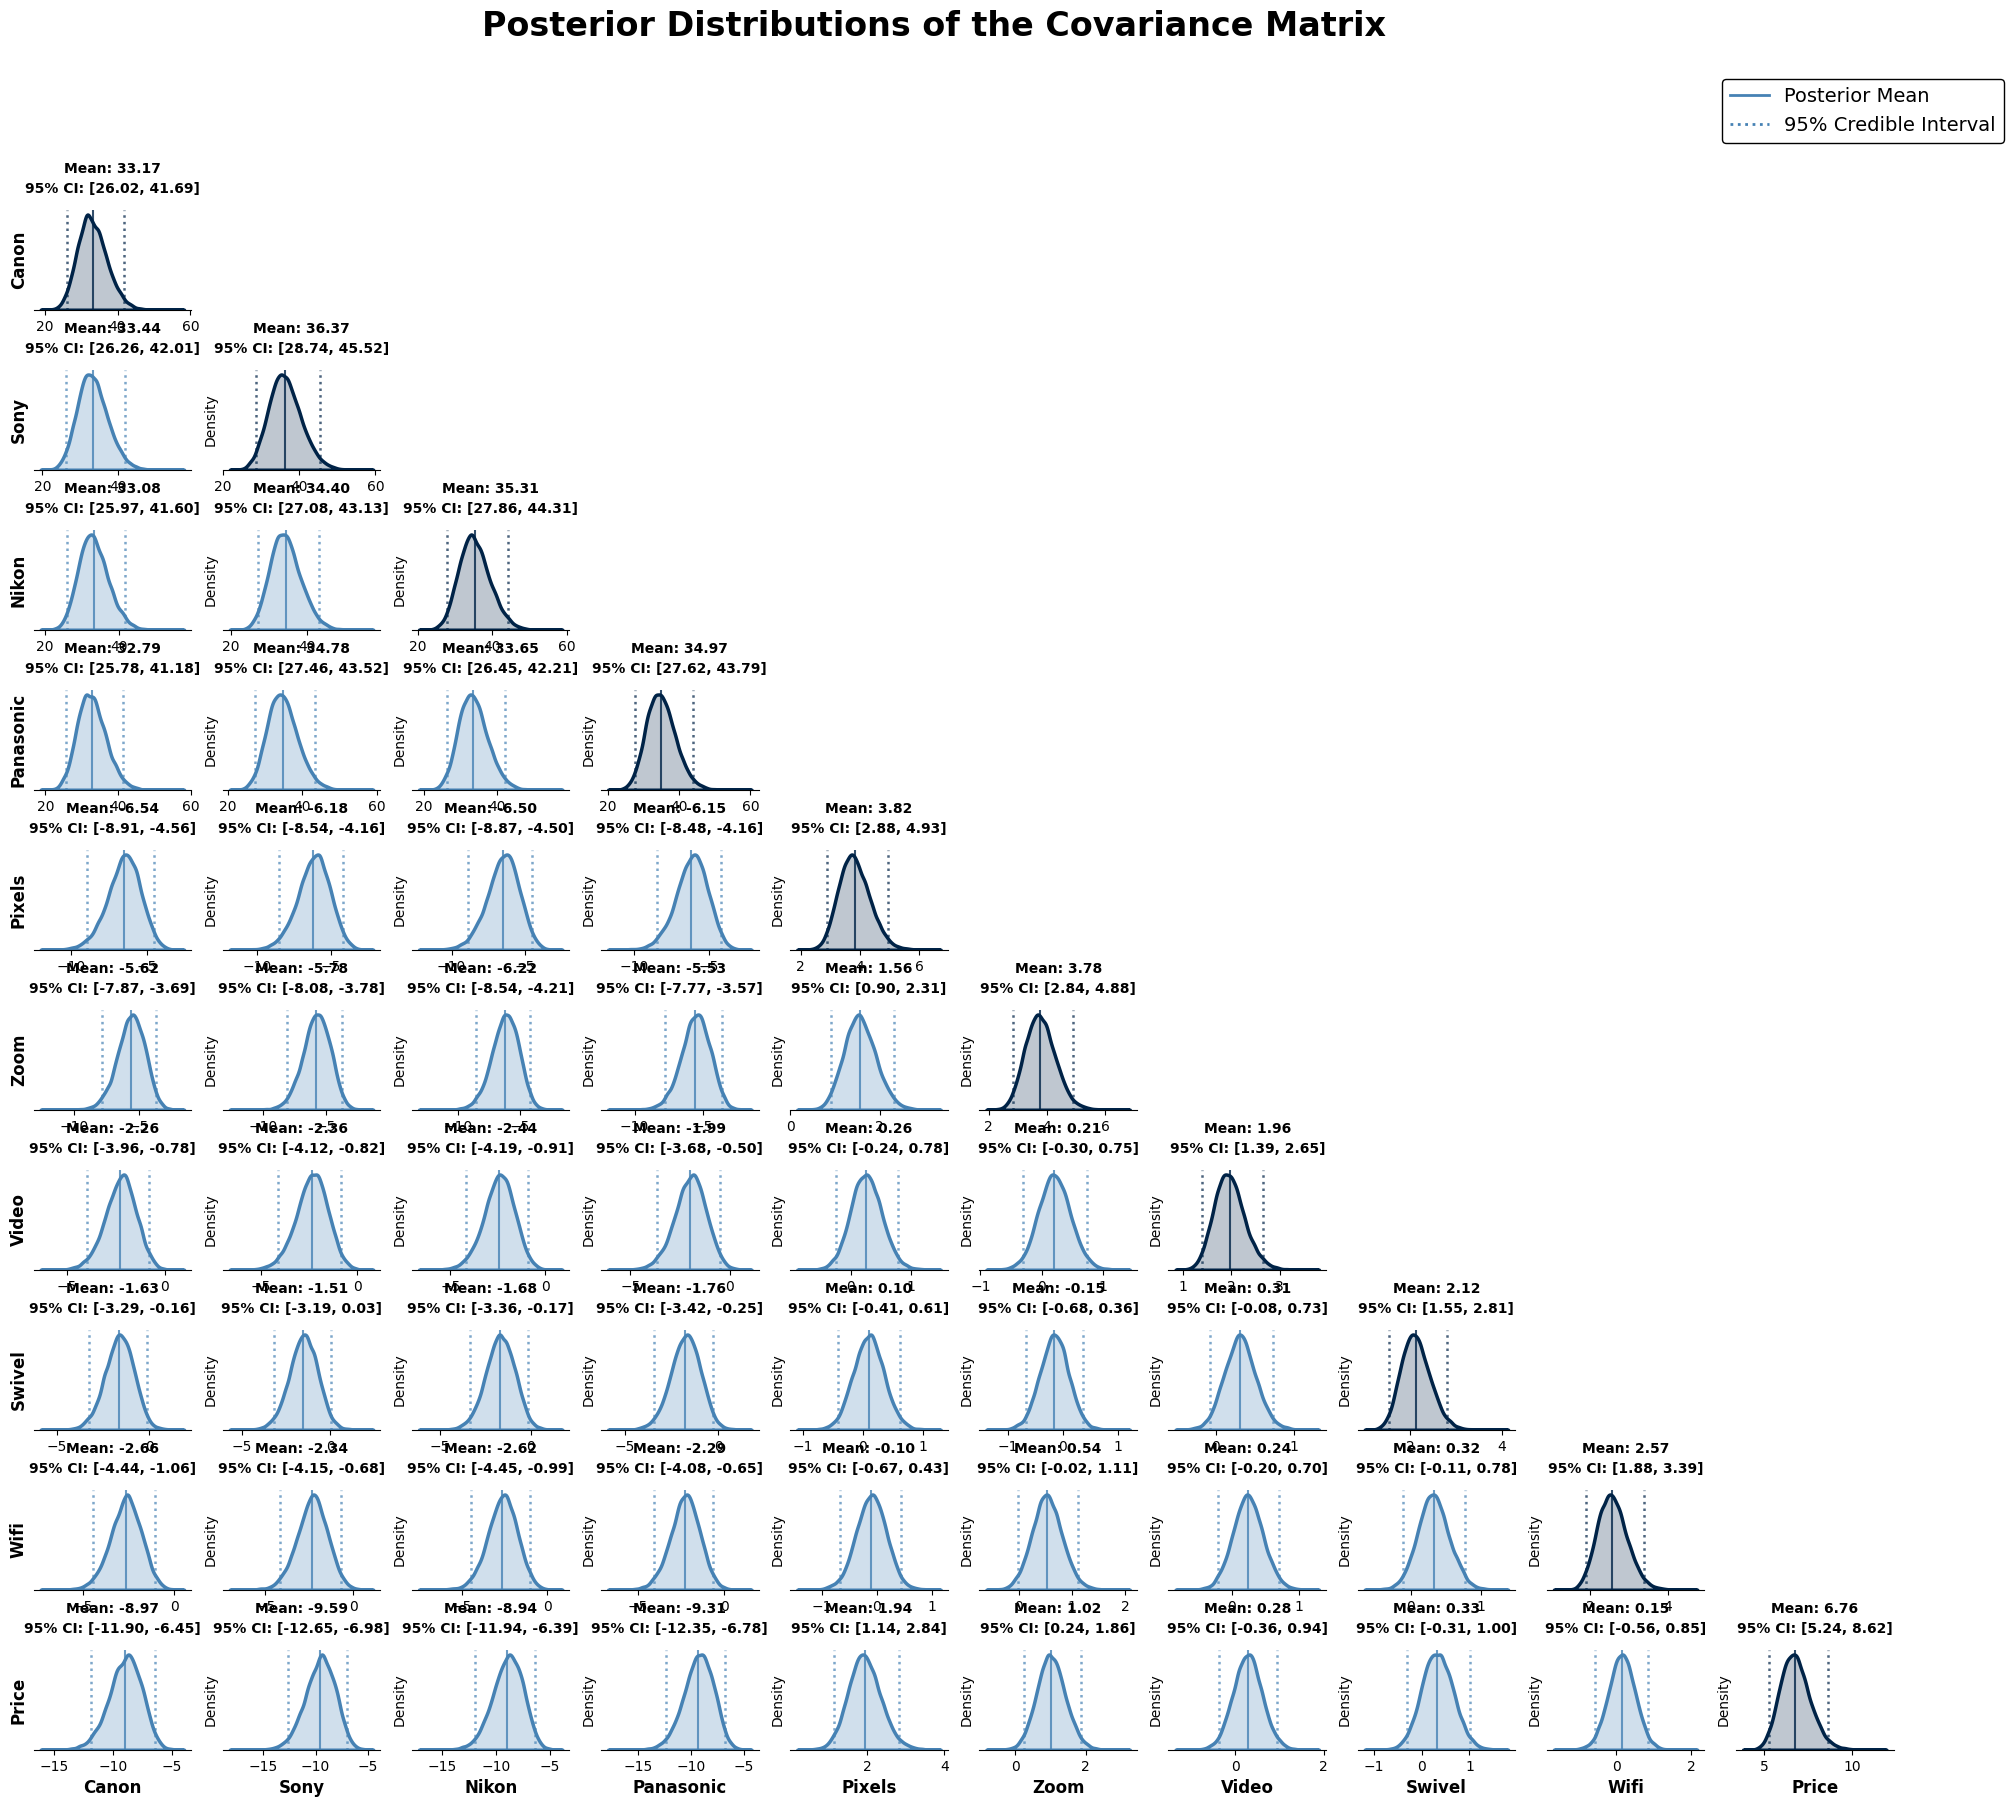

In [14]:
def plot_final_covariance_complete(sigma_samples, param_names, true_matrix=None, empirical_matrix=None):
    n_dim = sigma_samples.shape[-1]
    
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(24, 20))
    
    # Color Palette
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # Lower Triangular Logic
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = sigma_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            stats_str = " | ".join(title_parts)
            title_str = f"{stats_str}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(param_names[j], fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(param_names[i], fontsize=12, fontweight='bold')

    # Floating Legend
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
    ]
    if true_matrix is not None:
        legend_elements.append(Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'))
    if empirical_matrix is not None:
        legend_elements.append(Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Data Covariance'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.95, 0.95), 
               fontsize=14, frameon=True, edgecolor='black', framealpha=1, fancybox=True)

    plt.suptitle("Posterior Distributions of the Covariance Matrix", fontsize=24, y=0.98, fontweight='bold')
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# Extract Sigma Samples
k_dim = len(param_names)
latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
bijector = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

v_latent_to_sigma = jax.vmap(latent_to_sigma)
sigma_samples = np.array(v_latent_to_sigma(latent_samples))

# Plot the 10x10 Matrix
plot_final_covariance_complete(sigma_samples, param_names)


=== Global mu Trace Plots ===


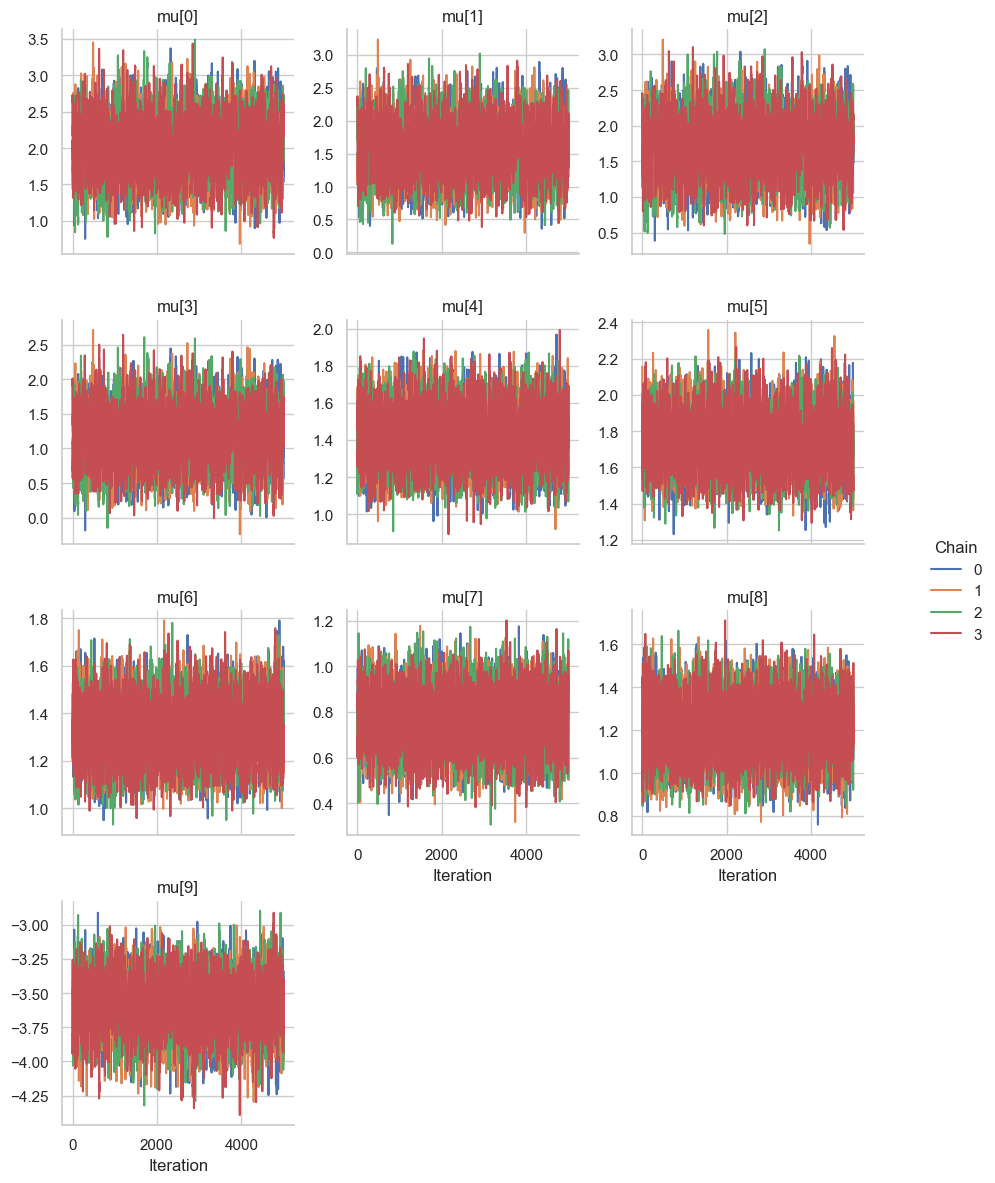


=== Detailed mu Parameter Diagnostics ===
Detailed Diagnostics: mu[0]


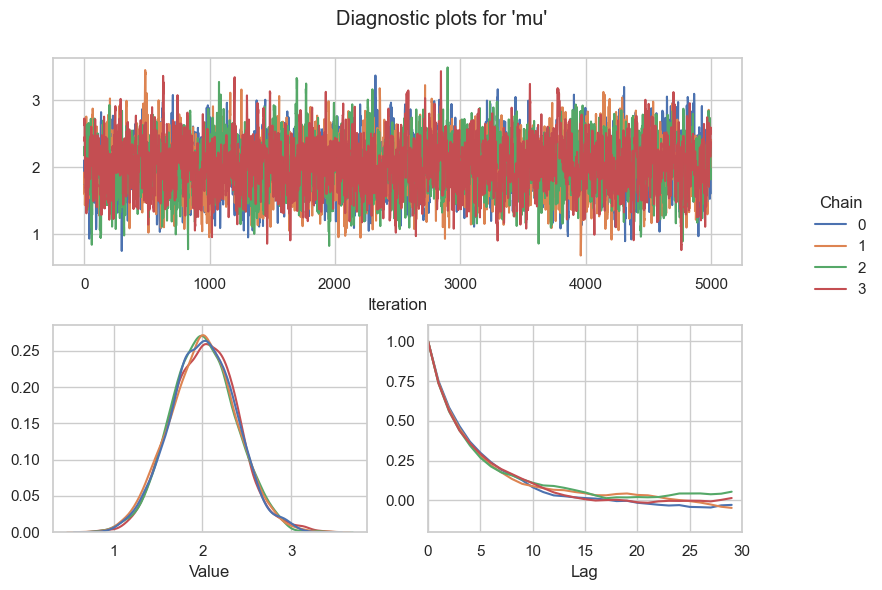

Detailed Diagnostics: mu[1]


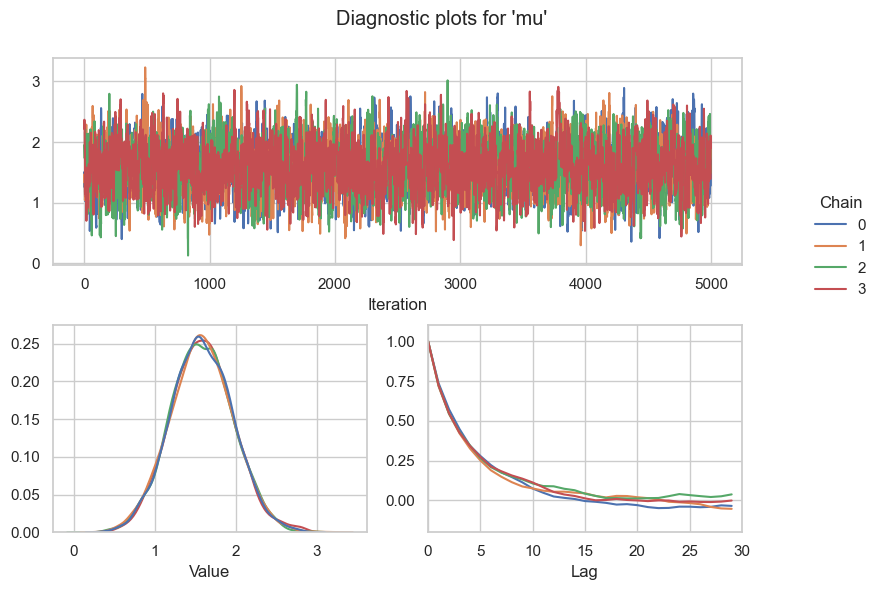

Detailed Diagnostics: mu[2]


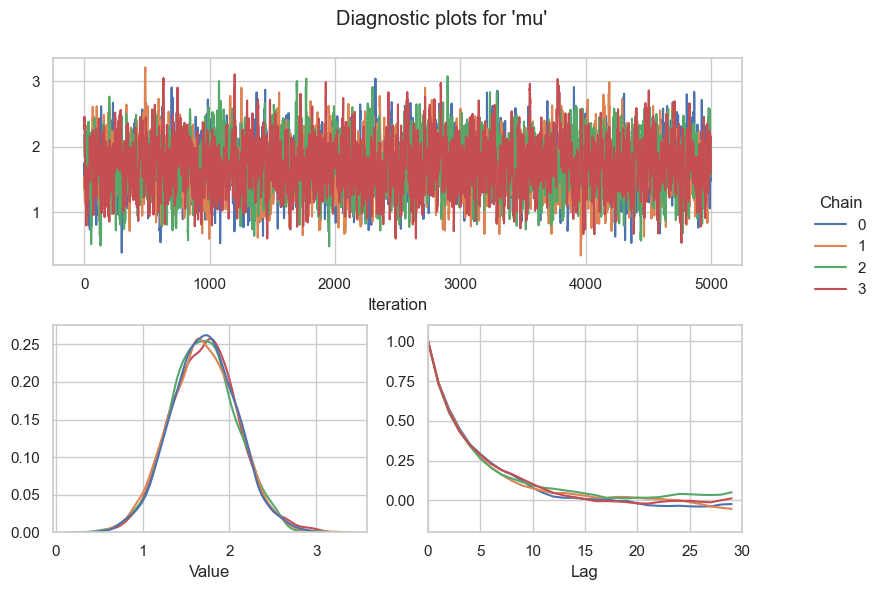

Detailed Diagnostics: mu[3]


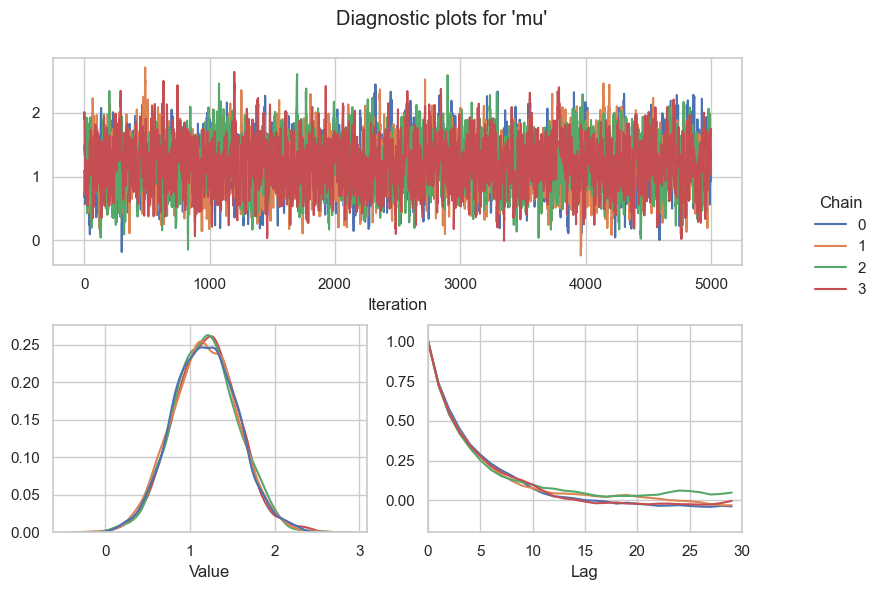

Detailed Diagnostics: mu[4]


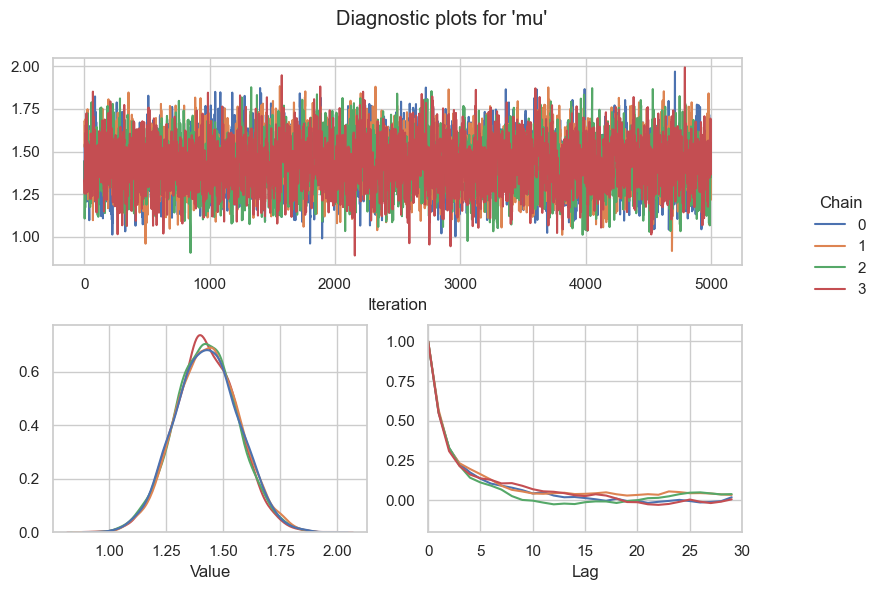

In [15]:
def plot_detailed_param(results_dict, param_name, param_indices):
    """Plot detailed diagnostics for a parameter."""
    if isinstance(param_indices, int):
        param_indices = [param_indices]
    for idx in param_indices:
        print(f"Detailed Diagnostics: {param_name}[{idx}]")
        gs.plot_param(results_dict, param_name, param_index=idx)
        plt.show()

global_param = "mu" if "mu" in samples else "Delta"

print(f"\n=== Global {global_param} Trace Plots ===")
gs.plot_trace(results, global_param)
plt.show()

print(f"\n=== Detailed {global_param} Parameter Diagnostics ===")
# Plot detailed diagnostics for the first 5 parameters to avoid overwhelming the notebook
plot_detailed_param(results, global_param, param_indices=range(5))
plt.show()